# Assignment 3 — ARMA, Seasonal Processes, and ARX Transfer Function Models
**Course:** Time Series Analysis 02417 _  Spring 2026 
**Semester:** 


This notebook is solution notebook for Assignment 3.  


- AR(2) simulation and autocorrelation analysis
- Seasonal AR forecasting for solar power
- ARX / transfer-function style modeling for heating demand



In [1]:
# Setup: import the main packages and use a simple plotting style.
# Tiny check: this cell should run without any error messages.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro, probplot

from pathlib import Path

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path(".")

# Part 1 — Stability and AR(2) simulations

We work with the AR(2) process

$$
X_t + \phi_1 X_{t-1} + \phi_2 X_{t-2} = \varepsilon_t,
\qquad \varepsilon_t \sim WN(0,1).
$$

Equivalently,

$$
X_t = -\phi_1 X_{t-1} - \phi_2 X_{t-2} + \varepsilon_t.
$$

The theoretical ACF of a **stationary** AR(2) process satisfies the recursion

$$
\rho(k) = -\phi_1 \rho(k-1) - \phi_2 \rho(k-2), \qquad k \ge 2,
$$

with

$$
\rho(0)=1,
\qquad
\rho(1)=\frac{-\phi_1}{1+\phi_2}.
$$

The next code cell defines reusable helper functions for:

- simulating the AR(2) process
- computing the roots of the characteristic polynomial
- checking stationarity
- computing the theoretical ACF when the process is stationary
- computing and plotting empirical ACFs from simulated realizations

In [2]:
# Helper functions for Part 1.
# Tiny check: this cell only defines functions, so no visible output is expected.
def simulate_ar2(n, phi1, phi2, sigma=1.0, seed=None):
    rng = np.random.default_rng(seed)

    eps = rng.normal(loc=0.0, scale=sigma, size=n)

    x = np.zeros(n)

    for t in range(2, n):
        x[t] = -phi1 * x[t - 1] - phi2 * x[t - 2] + eps[t]

    return x

def ar2_roots(phi1, phi2):
    coeffs = [phi2, phi1, 1.0]

    roots = np.roots(coeffs)

    return roots

def is_stationary_ar2(phi1, phi2):
    roots = ar2_roots(phi1, phi2)

    return np.all(np.abs(roots) > 1.0), roots

def theoretical_acf_ar2(phi1, phi2, max_lag=30):
    stationary, _ = is_stationary_ar2(phi1, phi2)
    if not stationary:
        return None

    rho = np.zeros(max_lag + 1)

    rho[0] = 1.0

    rho[1] = -phi1 / (1.0 + phi2)

    for k in range(2, max_lag + 1):
        rho[k] = -phi1 * rho[k - 1] - phi2 * rho[k - 2]

    return rho

def simulate_realizations_and_acfs(phi1, phi2, n=200, n_realizations=5, max_lag=30, seed=42):
    rng = np.random.default_rng(seed)

    realizations = []
    empirical_acfs = []

    for _ in range(n_realizations):
        one_seed = int(rng.integers(0, 10_000_000))
        x = simulate_ar2(n=n, phi1=phi1, phi2=phi2, sigma=1.0, seed=one_seed)
        realizations.append(x)
        empirical_acfs.append(acf(x, nlags=max_lag, fft=False))

    realizations = np.asarray(realizations)
    empirical_acfs = np.asarray(empirical_acfs)

    return realizations, empirical_acfs

def plot_ar2_experiment(phi1, phi2, n=200, n_realizations=5, max_lag=30, seed=42):
    realizations, empirical_acfs = simulate_realizations_and_acfs(
        phi1=phi1,
        phi2=phi2,
        n=n,
        n_realizations=n_realizations,
        max_lag=max_lag,
        seed=seed
    )

    rho_theoretical = theoretical_acf_ar2(phi1=phi1, phi2=phi2, max_lag=max_lag)

    stationary, roots = is_stationary_ar2(phi1=phi1, phi2=phi2)

    lags = np.arange(max_lag + 1)

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)

    for i in range(realizations.shape[0]):
        axes[0].plot(realizations[i], alpha=0.8, linewidth=1.1, label=f"Realization {i+1}")

    axes[0].set_title(
        f"Five AR(2) realizations: phi1 = {phi1}, phi2 = {phi2} | stationary = {stationary}"
    )
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("$X_t$")
    axes[0].legend(loc="upper right", ncol=2, fontsize=8)

    for i in range(empirical_acfs.shape[0]):
        axes[1].plot(lags, empirical_acfs[i], alpha=0.6, linewidth=1.0)

    axes[1].plot(lags, empirical_acfs.mean(axis=0), linewidth=2.2, label="Average empirical ACF")

    if rho_theoretical is not None:
        axes[1].plot(lags, rho_theoretical, linestyle="--", linewidth=2.2, label="Theoretical ACF")

    axes[1].axhline(0.0, color="black", linewidth=1.0)
    axes[1].set_title(
        f"Empirical ACFs up to lag {max_lag} | roots = {np.round(roots, 3)}"
    )
    axes[1].set_xlabel("Lag")
    axes[1].set_ylabel("ACF")
    axes[1].legend(loc="upper right")

    plt.show()

## Question 1.1 and 1.2 — Five realizations and empirical ACF together with $\rho(k)$

We first use

$$
\phi_1 = -0.6, \qquad \phi_2 = 0.5,
$$

simulate five realizations of length $n=200$, and compare the empirical ACFs with the theoretical ACF up to lag 30.

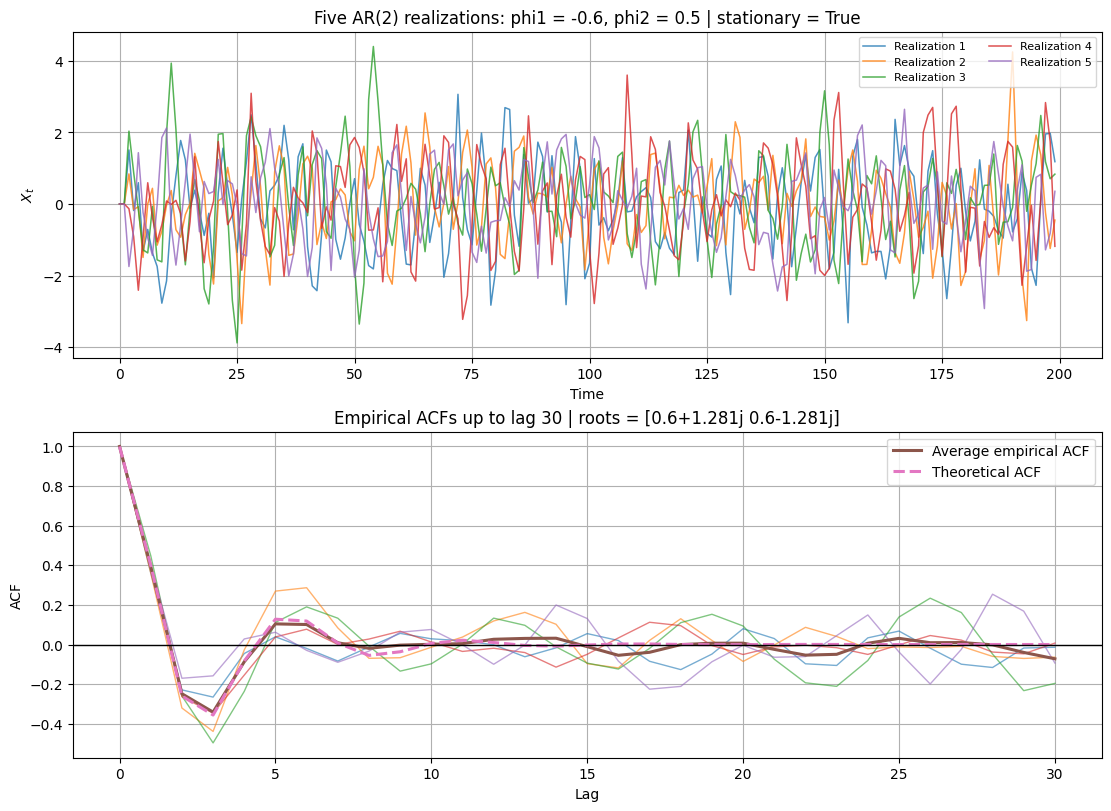

In [3]:
# Question 1.1-1.2: simulate five AR(2) realizations and compare empirical ACFs with the theoretical ACF.
# Tiny check: the process should look stationary and the average ACF should follow the dashed curve fairly well.
phi1 = -0.6
phi2 = 0.5

plot_ar2_experiment(phi1=phi1, phi2=phi2, n=200, n_realizations=5, max_lag=30, seed=42)

### What to notice
The five realizations should stay bounded and oscillatory rather than explode. In the ACF panel, the empirical curves should wobble around the theoretical pattern because the sample is finite.

## Questions 1.3 to 1.6 — Repeat the simulation and ACF analysis for new coefficient values

We now repeat the same idea for the four coefficient pairs requested in the assignment:

1. $(\phi_1, \phi_2)=(-0.6,-0.3)$
2. $(\phi_1, \phi_2)=(0.6,-0.3)$
3. $(\phi_1, \phi_2)=(-0.7,-0.3)$
4. $(\phi_1, \phi_2)=(-0.75,-0.3)$

The next cell prints a root table first, then produces the plots.

,phi1,phi2,root_1,root_2,abs(root_1),abs(root_2),stationary
0,-0.60,-0.3,-3.081666,1.081666,3.081666,1.081666,True
1,0.60,-0.3,3.081666,-1.081666,3.081666,1.081666,True
2,-0.70,-0.3,-3.333333,1.000000,3.333333,1.000000,False
3,-0.75,-0.3,-3.462653,0.962653,3.462653,0.962653,False


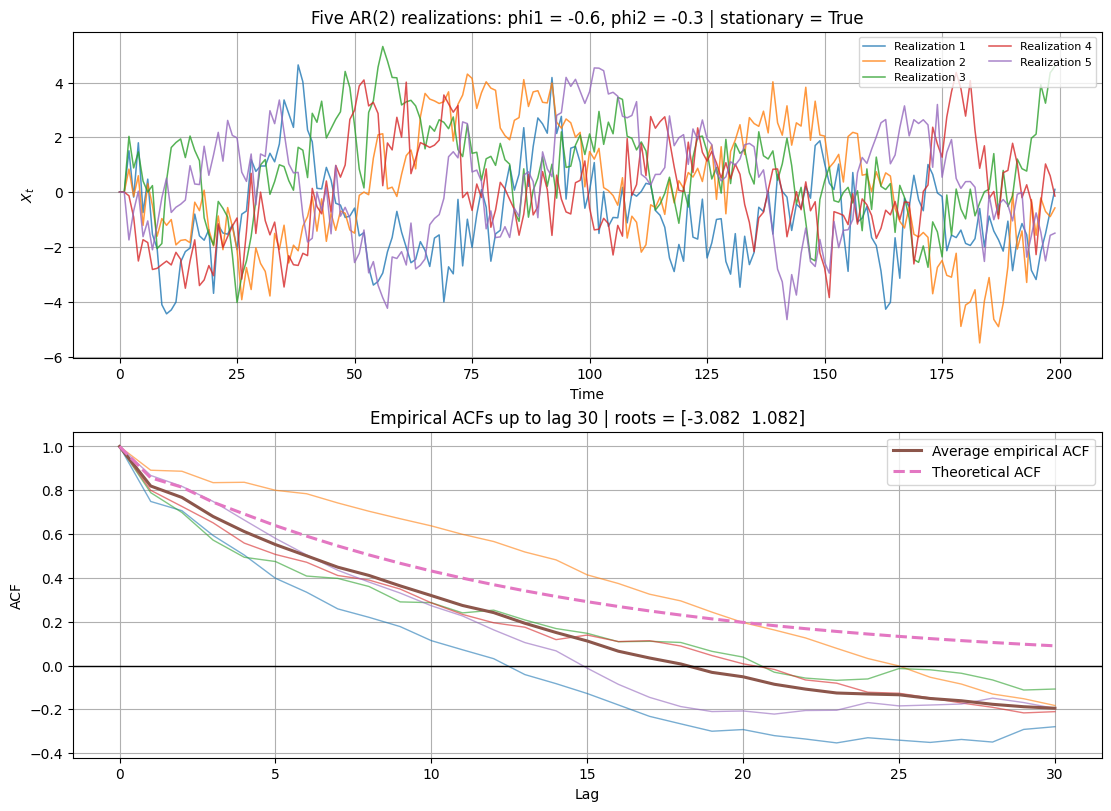

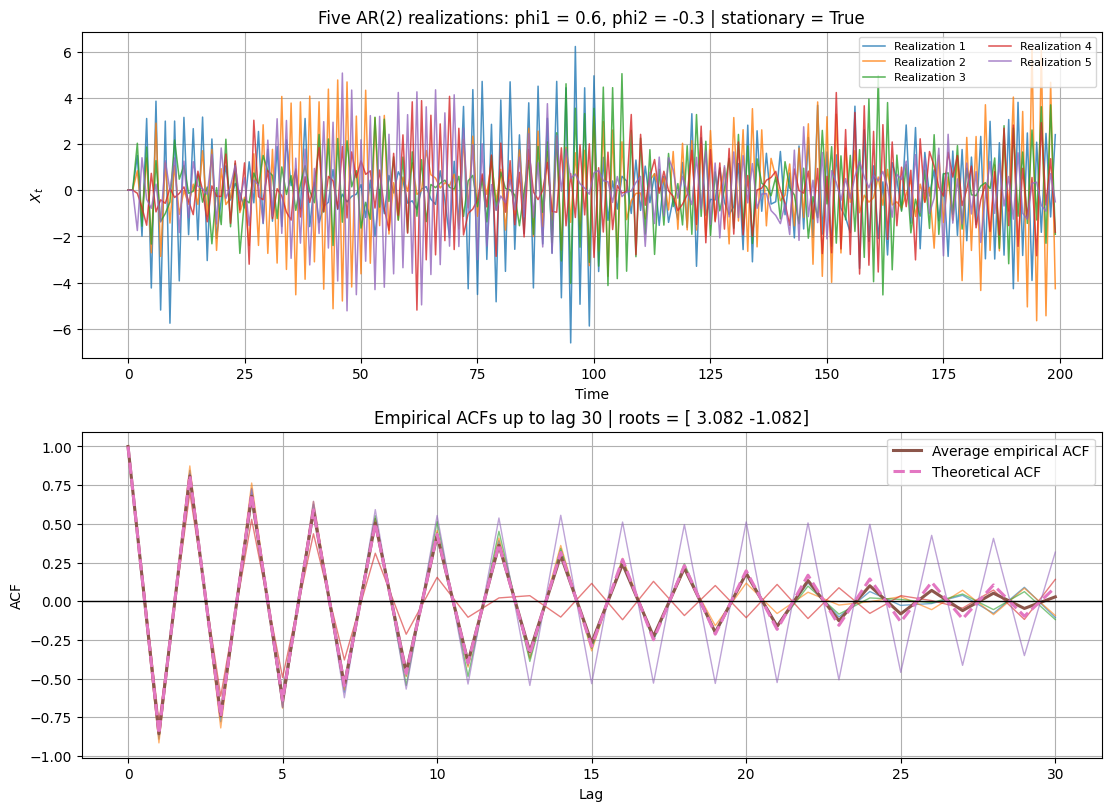

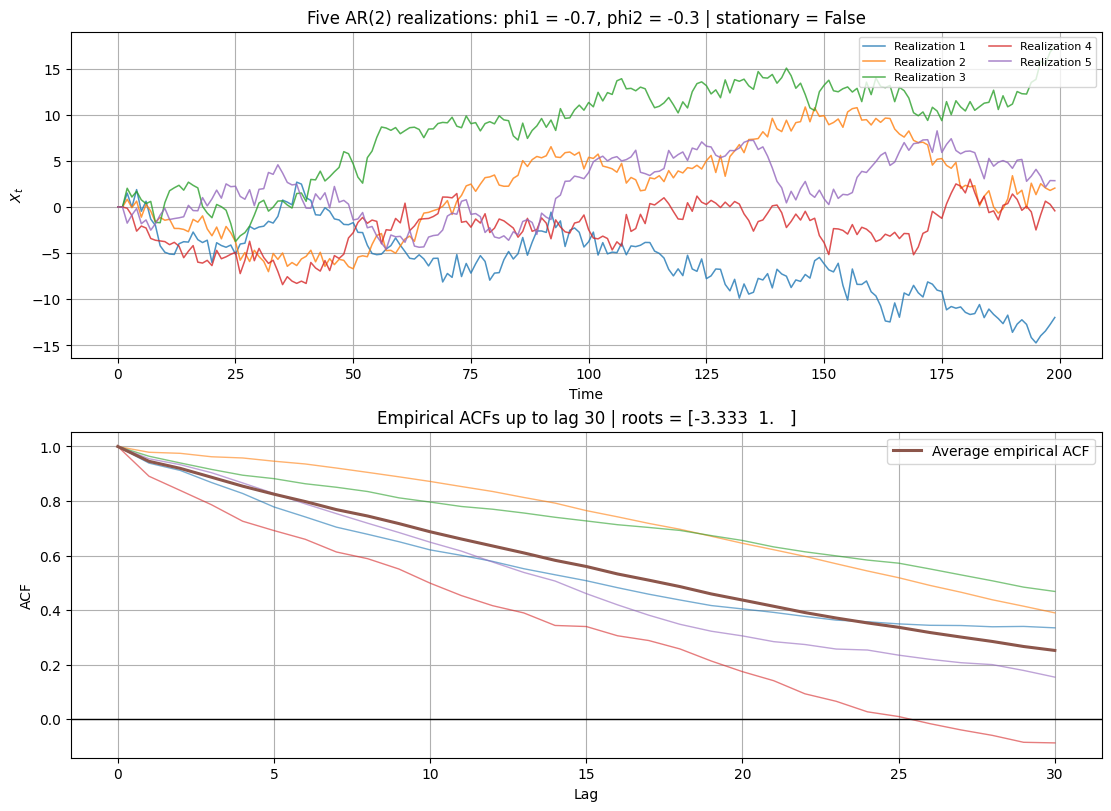

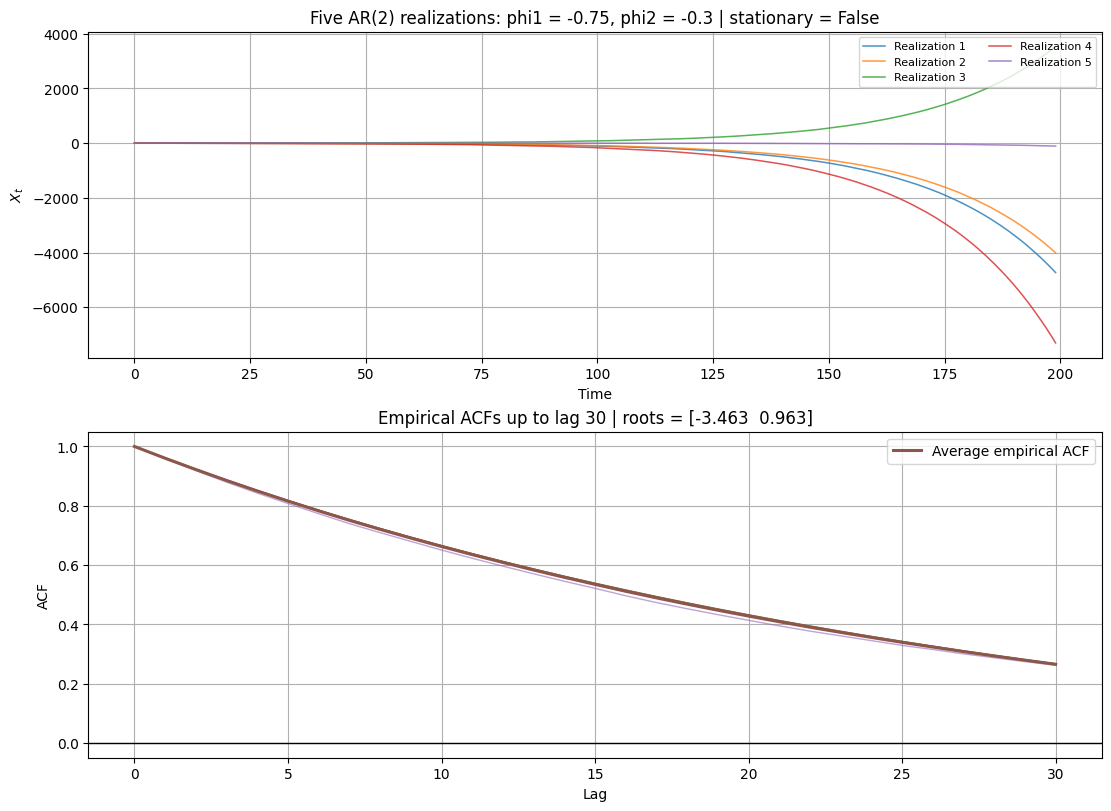

In [4]:
# Questions 1.3-1.6: repeat the AR(2) simulation for the remaining coefficient settings.
# Tiny check: compare the stable, boundary, and explosive cases side by side.
coefficient_cases = [
    (-0.6, -0.3),
    (0.6, -0.3),
    (-0.7, -0.3),
    (-0.75, -0.3),
]

summary_rows = []
for phi1_case, phi2_case in coefficient_cases:
    stationary, roots = is_stationary_ar2(phi1_case, phi2_case)
    summary_rows.append(
        {
            "phi1": phi1_case,
            "phi2": phi2_case,
            "root_1": roots[0],
            "root_2": roots[1],
            "abs(root_1)": np.abs(roots[0]),
            "abs(root_2)": np.abs(roots[1]),
            "stationary": stationary,
        }
    )

roots_table = pd.DataFrame(summary_rows)

display(roots_table)

for phi1_case, phi2_case in coefficient_cases:
    plot_ar2_experiment(phi1=phi1_case, phi2=phi2_case, n=200, n_realizations=5, max_lag=30, seed=42)

### What to notice
This comparison is the main visual story of Part 1. The stationary cases should stay bounded, the boundary case should decay very slowly, and the non-stationary case should look explosive.

## Question 1.7 — Should we always plot the time series, or is the ACF enough?

The short answer is: **use both**.

- The **time-series plot** is important for seeing non-stationarity directly, for example explosive behavior, slow drifting levels, or a visible change in variability.
- The **ACF** is important for understanding the serial dependence structure, but it does not always tell the whole story by itself.
- In near-nonstationary or explosive cases, the time-series plot is often the fastest way to see that something is wrong.

So the recommended workflow is:

1. **plot the series**
2. **inspect the ACF**
3. **check the roots / stationarity condition**

# Part 2 — Predicting monthly solar power

The given model is

$$
(1+\phi_1 B)(1+\Phi_1 B^{12})(\log(Y_t)-\mu) = \varepsilon_t,
$$

with known parameters

$$
\phi_1=-0.38, \qquad \Phi_1=-0.94, \qquad \mu=5.72, \qquad \sigma_\varepsilon^2=0.222.
$$

We define

$$
X_t = \log(Y_t) - \mu.
$$

Then the model becomes

$$
(1+\phi_1 B)(1+\Phi_1 B^{12})X_t = \varepsilon_t.
$$

Expanding the two lag polynomials gives

$$
X_t + \phi_1 X_{t-1} + \Phi_1 X_{t-12} + \phi_1\Phi_1 X_{t-13} = \varepsilon_t.
$$

## Question 2.1 — Read the data, rewrite the model, compute residuals, and validate i.i.d. errors

The next code cell:

- reads the monthly solar-power data
- constructs $X_t = \log(Y_t)-\mu$
- computes the one-step residuals
- validates the residuals using:
  - time-series plot
  - histogram
  - Q–Q plot
  - ACF
  - PACF
  - Ljung–Box test
  - Shapiro test

Residual mean       : 0.013384195643066026
Residual variance   : 0.044181334607360664
Given innovation var: 0.222


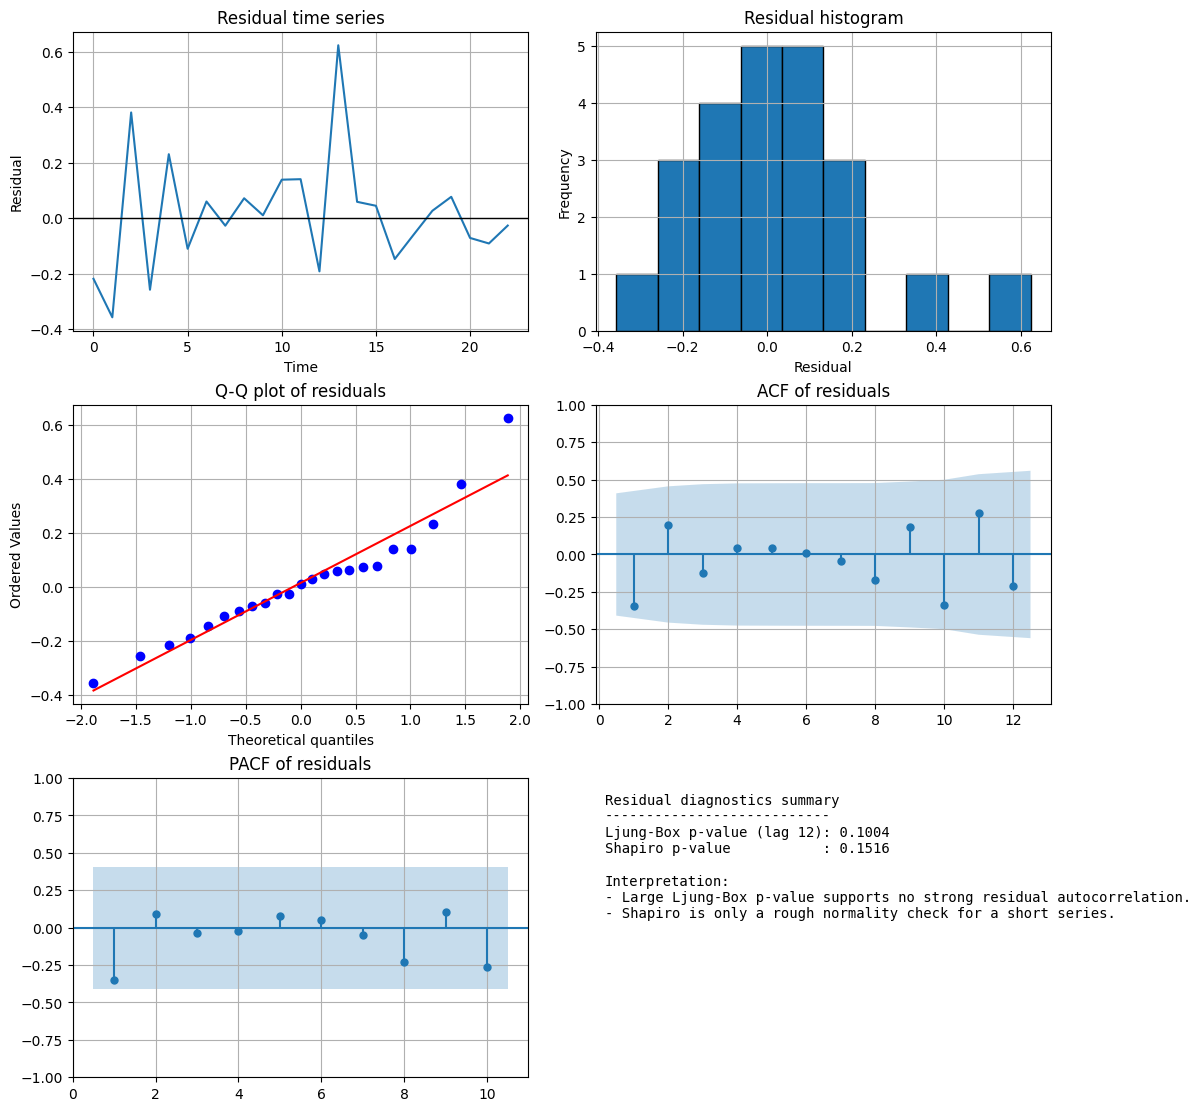

In [5]:
# Question 2.1: compute residuals for the given seasonal AR model and check the main assumptions.
# Tiny check: we want residuals centered near zero with no clear leftover dependence.
solar = pd.read_csv(DATA_DIR / "datasolar.csv")

Y = solar["power"].astype(float).to_numpy()

mu = 5.72
phi1 = -0.38
Phi1 = -0.94
sigma2_eps = 0.222

X = np.log(Y) - mu

residuals = np.full_like(X, fill_value=np.nan)

for t in range(13, len(X)):
    residuals[t] = X[t] + phi1 * X[t - 1] + Phi1 * X[t - 12] + phi1 * Phi1 * X[t - 13]

residuals_clean = residuals[~np.isnan(residuals)]

print("Residual mean       :", residuals_clean.mean())
print("Residual variance   :", residuals_clean.var(ddof=1))
print("Given innovation var:", sigma2_eps)

fig, axes = plt.subplots(3, 2, figsize=(12, 11), constrained_layout=True)

axes[0, 0].plot(residuals_clean)
axes[0, 0].axhline(0.0, color="black", linewidth=1.0)
axes[0, 0].set_title("Residual time series")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Residual")

axes[0, 1].hist(residuals_clean, bins=10, edgecolor="black")
axes[0, 1].set_title("Residual histogram")
axes[0, 1].set_xlabel("Residual")
axes[0, 1].set_ylabel("Frequency")

probplot(residuals_clean, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q plot of residuals")

plot_acf(residuals_clean, lags=12, ax=axes[1, 1], zero=False)
axes[1, 1].set_title("ACF of residuals")

pacf_lags = min(10, max(1, len(residuals_clean) // 2 - 1))
plot_pacf(residuals_clean, lags=pacf_lags, ax=axes[2, 0], zero=False, method="ywm")
axes[2, 0].set_title("PACF of residuals")

axes[2, 1].axis("off")
lb = acorr_ljungbox(residuals_clean, lags=[12], return_df=True)
shapiro_stat, shapiro_p = shapiro(residuals_clean)
axes[2, 1].text(
    0.02,
    0.95,
    "\n".join(
        [
            "Residual diagnostics summary",
            "---------------------------",
            f"Ljung-Box p-value (lag 12): {lb['lb_pvalue'].iloc[0]:.4f}",
            f"Shapiro p-value           : {shapiro_p:.4f}",
            "",
            "Interpretation:",
            "- Large Ljung-Box p-value supports no strong residual autocorrelation.",
            "- Shapiro is only a rough normality check for a short series.",
        ]
    ),
    va="top",
    family="monospace",
)

plt.show()

### What to notice
For this validation step, a good sign is that the residuals look roughly centered around zero and that the ACF does not show a strong leftover pattern. With only 23 effective residuals, small irregularities are normal.

## Questions 2.2 and 2.3 — 12-step forecast and 95% prediction intervals

For the point forecast, we recursively use

$$
\hat X_{t+k|t}
=
-\phi_1 \hat X_{t+k-1|t}
-\Phi_1 X_{t+k-12}
-\phi_1\Phi_1 X_{t+k-13},
$$

taking observed past values when they are available and forecasted values when the recursion reaches into the future.

Then we transform back to power using

$$
\hat Y_{t+k|t} = \exp(\hat X_{t+k|t} + \mu).
$$

For the 95% prediction intervals, the assignment explicitly says to use only the **AR(1)** part.  
So we use the AR(1) model

$$
X_t + \phi_1 X_{t-1} = \varepsilon_t,
$$

which in standard form is

$$
X_t = a X_{t-1} + \varepsilon_t
\qquad \text{with} \qquad
a = -\phi_1.
$$

Hence, the $k$-step forecast error variance is

$$
\sigma_k^2 = \sigma_\varepsilon^2 \sum_{i=0}^{k-1} a^{2i}.
$$

,Month,Forecast_MWh,Lower_95,Upper_95
0,2011-01,101.28,40.22,255.03
1,2011-02,147.23,54.82,395.39
2,2011-03,156.92,57.91,425.23
3,2011-04,142.55,52.54,386.78
4,2011-05,355.31,130.93,964.24
5,2011-06,538.02,198.25,1460.12
6,2011-07,611.21,225.21,1658.74
7,2011-08,631.89,232.84,1714.89
8,2011-09,630.11,232.18,1710.05
9,2011-10,508.16,187.24,1379.08


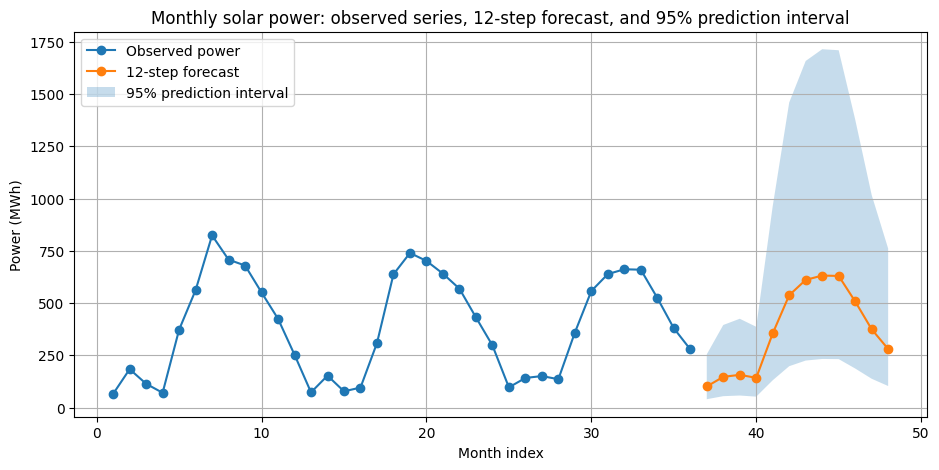

In [6]:
# Questions 2.2-2.3: make the 12-step forecast and add 95% prediction intervals.
# Tiny check: the seasonal pattern should stay visible after the back-transformation.
h = 12

X_extended = np.concatenate([X, np.full(h, np.nan)])

for k in range(1, h + 1):
    idx = len(X) + k - 1

    x_lag1 = X_extended[idx - 1]
    x_lag12 = X_extended[idx - 12]
    x_lag13 = X_extended[idx - 13]

    X_extended[idx] = -phi1 * x_lag1 - Phi1 * x_lag12 - phi1 * Phi1 * x_lag13

X_forecast = X_extended[len(X):]

Y_forecast = np.exp(X_forecast + mu)

future_periods = pd.period_range(start="2011-01", periods=12, freq="M")

a = -phi1
sigma_k = np.sqrt(
    sigma2_eps * np.array([sum(a ** (2 * i) for i in range(k)) for k in range(1, h + 1)])
)

lower_95 = np.exp(X_forecast + mu - 1.96 * sigma_k)
upper_95 = np.exp(X_forecast + mu + 1.96 * sigma_k)

forecast_table = pd.DataFrame(
    {
        "Month": future_periods.astype(str),
        "Forecast_MWh": np.round(Y_forecast, 2),
        "Lower_95": np.round(lower_95, 2),
        "Upper_95": np.round(upper_95, 2),
    }
)

display(forecast_table)

fig, ax = plt.subplots(figsize=(11, 5))

observed_index = np.arange(1, len(Y) + 1)
ax.plot(observed_index, Y, marker="o", label="Observed power")

forecast_index = np.arange(len(Y) + 1, len(Y) + h + 1)
ax.plot(forecast_index, Y_forecast, marker="o", label="12-step forecast")

ax.fill_between(forecast_index, lower_95, upper_95, alpha=0.25, label="95% prediction interval")

ax.set_title("Monthly solar power: observed series, 12-step forecast, and 95% prediction interval")
ax.set_xlabel("Month index")
ax.set_ylabel("Power (MWh)")
ax.legend()
plt.show()

### What to notice
The forecast should keep the annual seasonal shape: lower winter production and a summer peak. The intervals widen on the original scale after exponentiation, so some asymmetry is expected.

## Question 2.4 — Brief comment on trust and interval width

The point forecast reproduces the strong annual seasonality quite well because the model explicitly contains a seasonal lag of 12.  
However, this forecast should still be treated with some care:

- the sample is short (36 observations)
- the model is fixed and assumes the same dynamics continue unchanged
- the prediction interval is only based on the **non-seasonal AR(1)** part, exactly as requested in the assignment

So the interval is useful as a course-based approximation, but it may not fully reflect the true uncertainty of the seasonal process in every month.

# Part 3 — ARX model for the heating of a box

We now model the heating demand $Ph_t$ using the exogenous inputs:

- $Tdelta_t$ = temperature difference
- $Gv_t$ = vertical solar radiation

The assignment asks for:

- exploratory plots
- impulse-response estimation
- a simple linear regression model
- ARX(1)
- higher-order ARX models
- AIC / BIC comparison
- one-step test RMSE comparison
- multi-step simulation using the selected model order

## Question 3.1 — Read the data and plot the three non-lagged series

The next code cell loads the box data, converts the timestamp to datetime format, and plots:

- $Ph$
- $Tdelta$
- $Gv$

in three aligned panels.

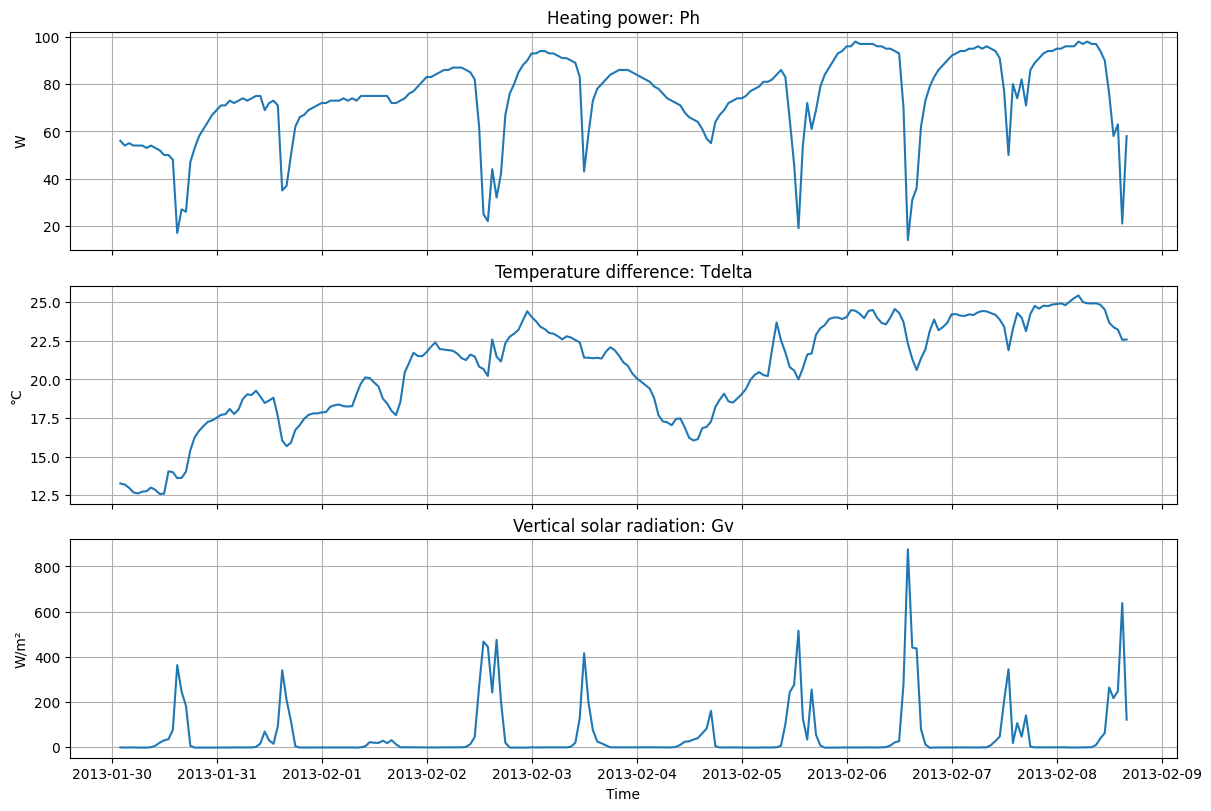

In [7]:
# Question 3.1: plot the three observed box variables.
# Tiny check: look for daily structure and for a likely negative link between Gv and Ph.
box = pd.read_csv(DATA_DIR / "box_data_60min.csv")

box["tdate"] = pd.to_datetime(box["tdate"])

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, constrained_layout=True)

axes[0].plot(box["tdate"], box["Ph"])
axes[0].set_title("Heating power: Ph")
axes[0].set_ylabel("W")

axes[1].plot(box["tdate"], box["Tdelta"])
axes[1].set_title("Temperature difference: Tdelta")
axes[1].set_ylabel("°C")

axes[2].plot(box["tdate"], box["Gv"])
axes[2].set_title("Vertical solar radiation: Gv")
axes[2].set_ylabel("W/m²")
axes[2].set_xlabel("Time")

plt.show()

### What to notice
Ph should show clear daily variation, Tdelta should move more smoothly, and Gv should be near zero at night. This first plot already gives a simple physical picture of the system.

## Question 3.2 — Split the data into train and test sets

The assignment states that **2013-02-06 00:00** is the last training time point.  
So we split the data exactly at that timestamp.

In [8]:
# Question 3.2: split the data exactly at the assignment cut-off time.
# Tiny check: the training size should be 167 and the test size should be 64.
train_end = pd.Timestamp("2013-02-06 00:00:00")

train = box[box["tdate"] <= train_end].copy()
test = box[box["tdate"] > train_end].copy()

print("Training observations:", len(train))
print("Test observations    :", len(test))

print("\nTraining period:")
print(train["tdate"].min(), "to", train["tdate"].max())

print("\nTest period:")
print(test["tdate"].min(), "to", test["tdate"].max())

Training observations: 167
Test observations    : 64

Training period:
2013-01-30 02:00:00 to 2013-02-06 00:00:00

Test period:
2013-02-06 01:00:00 to 2013-02-08 16:00:00


### Quick note
These printed sizes are an easy safety check. They should match the assignment split exactly before you continue with the modeling.

## Question 3.3 — Investigate the variables and their relations

We focus on $Ph$ and inspect:

- scatter plots: $Ph$ versus $Tdelta$ and $Ph$ versus $Gv$
- ACF plots for the three series
- cross-correlation plots between the inputs and $Ph$

To keep the notebook fully Python-only, the cross-correlation plot is implemented manually.

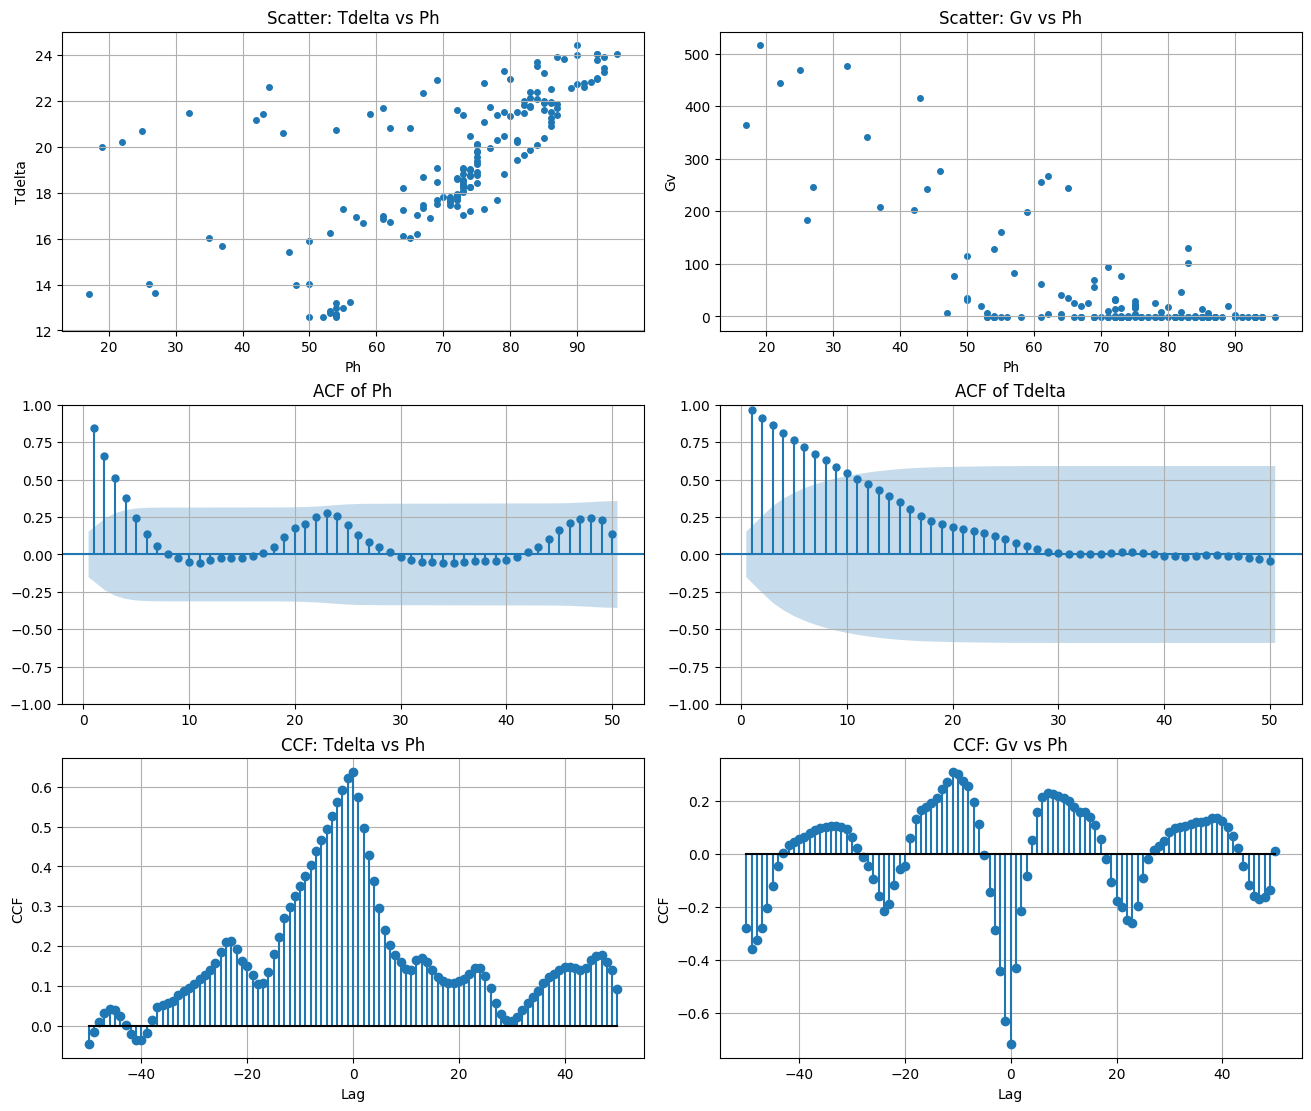

In [9]:
# Question 3.3: inspect scatter plots, ACFs, and cross-correlations on the training set.
# Tiny check: this is a quick way to see whether a dynamic ARX-style model is reasonable.
def sample_ccf(x, y, max_lag=50):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x = x - x.mean()
    y = y - y.mean()

    denom = np.sqrt(np.sum(x ** 2) * np.sum(y ** 2))

    lags = np.arange(-max_lag, max_lag + 1)
    corrs = []

    for lag in lags:
        if lag < 0:
            x_lag = x[:lag]
            y_lag = y[-lag:]
        elif lag > 0:
            x_lag = x[lag:]
            y_lag = y[:-lag]
        else:
            x_lag = x
            y_lag = y

        corrs.append(np.sum(x_lag * y_lag) / denom)

    return lags, np.asarray(corrs)

fig, axes = plt.subplots(3, 2, figsize=(13, 11), constrained_layout=True)

axes[0, 0].scatter(train["Ph"], train["Tdelta"], s=16)
axes[0, 0].set_title("Scatter: Tdelta vs Ph")
axes[0, 0].set_xlabel("Ph")
axes[0, 0].set_ylabel("Tdelta")

axes[0, 1].scatter(train["Ph"], train["Gv"], s=16)
axes[0, 1].set_title("Scatter: Gv vs Ph")
axes[0, 1].set_xlabel("Ph")
axes[0, 1].set_ylabel("Gv")

plot_acf(train["Ph"], lags=50, ax=axes[1, 0], zero=False)
axes[1, 0].set_title("ACF of Ph")

plot_acf(train["Tdelta"], lags=50, ax=axes[1, 1], zero=False)
axes[1, 1].set_title("ACF of Tdelta")

lags_td, ccf_td = sample_ccf(train["Tdelta"], train["Ph"], max_lag=50)
axes[2, 0].stem(lags_td, ccf_td, linefmt="C0-", markerfmt="C0o", basefmt="k-")
axes[2, 0].set_title("CCF: Tdelta vs Ph")
axes[2, 0].set_xlabel("Lag")
axes[2, 0].set_ylabel("CCF")

lags_gv, ccf_gv = sample_ccf(train["Gv"], train["Ph"], max_lag=50)
axes[2, 1].stem(lags_gv, ccf_gv, linefmt="C0-", markerfmt="C0o", basefmt="k-")
axes[2, 1].set_title("CCF: Gv vs Ph")
axes[2, 1].set_xlabel("Lag")
axes[2, 1].set_ylabel("CCF")

plt.show()

### What to notice
A positive Ph–Tdelta relation and a negative Ph–Gv relation are both expected. Strong serial dependence in Ph, together with visible cross-correlation, is a good hint that a static model alone may be too weak.

## Question 3.4 — Estimate the impulse response from $Tdelta$ and $Gv$ to $Ph$ up to lag 10

A simple course-aligned way to estimate a finite impulse response is to regress $Ph_t$ on lags 0 to 10 of one input at a time:

$$
Ph_t = \sum_{k=0}^{10} \beta_k^{(T)} Tdelta_{t-k} + \varepsilon_t,
$$

and

$$
Ph_t = \sum_{k=0}^{10} \beta_k^{(G)} Gv_{t-k} + \varepsilon_t.
$$

The estimated coefficients are interpreted as empirical impulse-response weights.

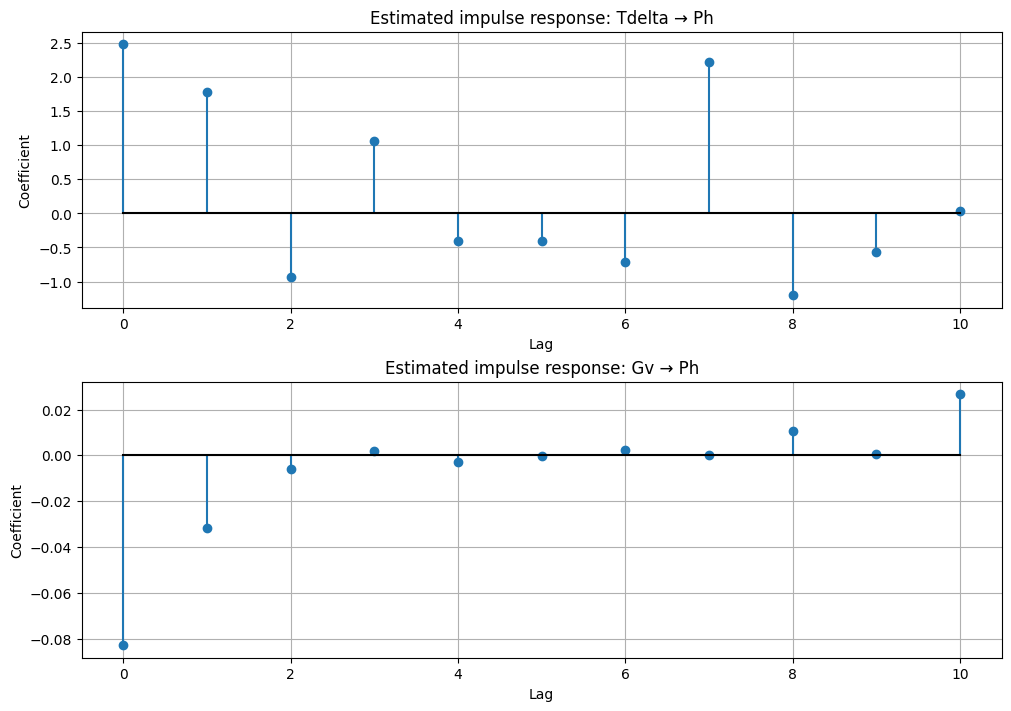

,lag,Tdelta_to_Ph,Gv_to_Ph
0,0,2.4800,-0.0829
1,1,1.7800,-0.0316
2,2,-0.9352,-0.0059
3,3,1.0648,0.0019
4,4,-0.4102,-0.0027
5,5,-0.4078,-0.0005
6,6,-0.7190,0.0022
7,7,2.2154,0.0003
8,8,-1.1994,0.0107
9,9,-0.5630,0.0005


In [10]:
# Question 3.4: estimate simple finite impulse responses up to lag 10.
# Tiny check: Tdelta should have a positive effect and Gv should mainly have a negative contemporaneous effect.
tdelta_lag_cols = [f"Tdelta.l{k}" for k in range(0, 11)]
gv_lag_cols = [f"Gv.l{k}" for k in range(0, 11)]

X_tdelta = sm.add_constant(train[tdelta_lag_cols], has_constant="add")
fir_tdelta = sm.OLS(train["Ph"], X_tdelta).fit()

X_gv = sm.add_constant(train[gv_lag_cols], has_constant="add")
fir_gv = sm.OLS(train["Ph"], X_gv).fit()

impulse_tdelta = pd.Series(fir_tdelta.params[tdelta_lag_cols].to_numpy(), index=np.arange(0, 11))
impulse_gv = pd.Series(fir_gv.params[gv_lag_cols].to_numpy(), index=np.arange(0, 11))

fig, axes = plt.subplots(2, 1, figsize=(10, 7), constrained_layout=True)

axes[0].stem(impulse_tdelta.index, impulse_tdelta.values, linefmt="C0-", markerfmt="C0o", basefmt="k-")
axes[0].set_title("Estimated impulse response: Tdelta → Ph")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Coefficient")

axes[1].stem(impulse_gv.index, impulse_gv.values, linefmt="C0-", markerfmt="C0o", basefmt="k-")
axes[1].set_title("Estimated impulse response: Gv → Ph")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Coefficient")

plt.show()

impulse_table = pd.DataFrame(
    {
        "lag": np.arange(0, 11),
        "Tdelta_to_Ph": np.round(impulse_tdelta.values, 4),
        "Gv_to_Ph": np.round(impulse_gv.values, 4),
    }
)
display(impulse_table)

### What to notice
This cell gives a simple lag-by-lag picture of the input effects. A spread-out positive response for Tdelta and a mainly negative lag-0 response for Gv are both physically sensible here.

## Question 3.5 — Fit the linear regression model

We first fit the simple static model

$$
Ph_t = \omega_1 Tdelta_t + \omega_2 Gv_t + \varepsilon_t,
$$

assuming i.i.d. errors.

Then we create **expanding-window one-step predictions** on the training set to inspect the residual structure more realistically.

,coefficient,estimate
0,const,11.148419
1,Tdelta,3.335743
2,Gv,-0.111414


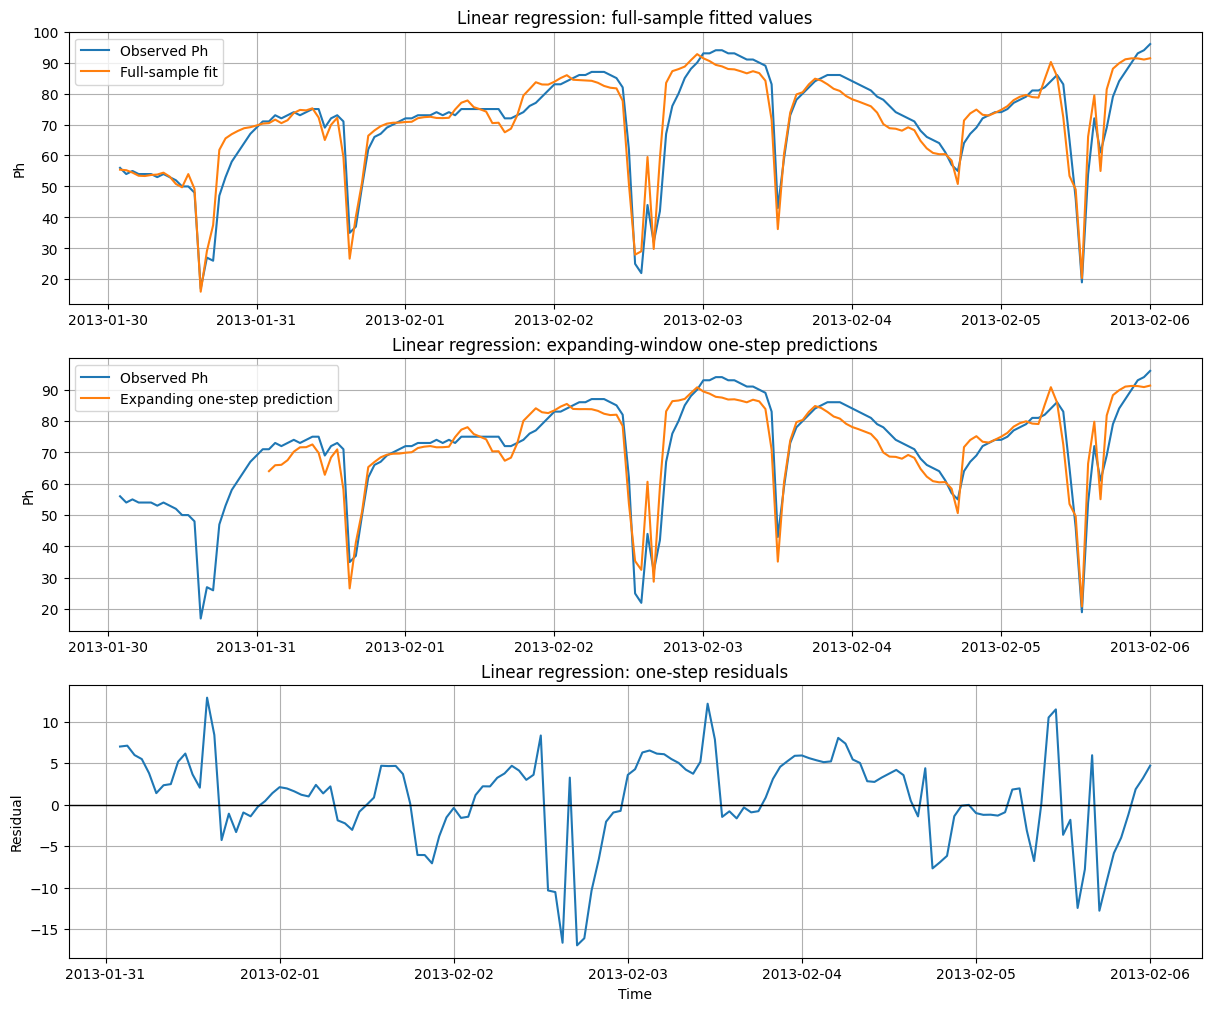

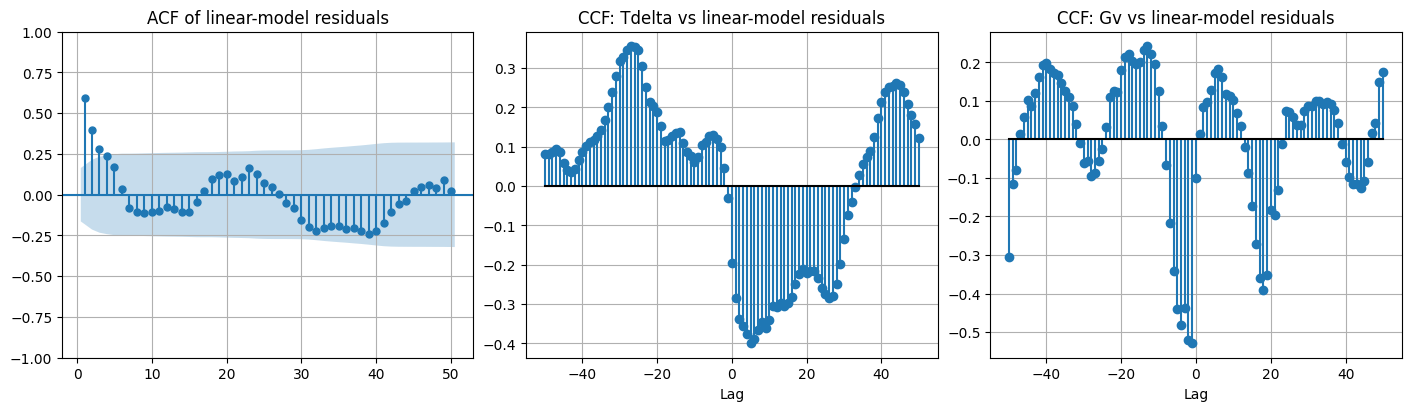

In [11]:
# Question 3.5: fit the static regression and inspect one-step diagnostics.
# Tiny check: if the residual ACF still shows structure, the simple regression is probably not enough.
def expanding_one_step_predictions(df, feature_cols, target_col="Ph", min_train_size=24):
    predictions = np.full(len(df), np.nan)
    residuals = np.full(len(df), np.nan)

    for t in range(min_train_size, len(df)):
        train_slice = df.iloc[:t]

        X_train = sm.add_constant(train_slice[feature_cols], has_constant="add")
        y_train = train_slice[target_col]
        model = sm.OLS(y_train, X_train).fit()

        X_next = sm.add_constant(df.iloc[[t]][feature_cols], has_constant="add")
        y_pred = model.predict(X_next).iloc[0]

        predictions[t] = y_pred
        residuals[t] = df.iloc[t][target_col] - y_pred

    return predictions, residuals

linear_features = ["Tdelta", "Gv"]

linear_model = sm.OLS(train["Ph"], sm.add_constant(train[linear_features], has_constant="add")).fit()

train_linear_fitted = linear_model.predict(sm.add_constant(train[linear_features], has_constant="add"))

train_linear_pred, train_linear_resid = expanding_one_step_predictions(
    df=train,
    feature_cols=linear_features,
    target_col="Ph",
    min_train_size=24,
)

linear_diag = train[["tdate", "Ph", "Tdelta", "Gv"]].copy()
linear_diag["fitted_full_sample"] = train_linear_fitted
linear_diag["one_step_pred"] = train_linear_pred
linear_diag["one_step_resid"] = train_linear_resid

display(pd.DataFrame({"coefficient": linear_model.params.index, "estimate": linear_model.params.values}))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

axes[0].plot(linear_diag["tdate"], linear_diag["Ph"], label="Observed Ph")
axes[0].plot(linear_diag["tdate"], linear_diag["fitted_full_sample"], label="Full-sample fit")
axes[0].set_title("Linear regression: full-sample fitted values")
axes[0].set_ylabel("Ph")
axes[0].legend()

axes[1].plot(linear_diag["tdate"], linear_diag["Ph"], label="Observed Ph")
axes[1].plot(linear_diag["tdate"], linear_diag["one_step_pred"], label="Expanding one-step prediction")
axes[1].set_title("Linear regression: expanding-window one-step predictions")
axes[1].set_ylabel("Ph")
axes[1].legend()

axes[2].plot(linear_diag["tdate"], linear_diag["one_step_resid"])
axes[2].axhline(0.0, color="black", linewidth=1.0)
axes[2].set_title("Linear regression: one-step residuals")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Residual")

plt.show()

resid_clean = linear_diag["one_step_resid"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

plot_acf(resid_clean, lags=50, ax=axes[0], zero=False)
axes[0].set_title("ACF of linear-model residuals")

lags_td, ccf_td_res = sample_ccf(linear_diag.loc[resid_clean.index, "Tdelta"], resid_clean, max_lag=50)
axes[1].stem(lags_td, ccf_td_res, linefmt="C0-", markerfmt="C0o", basefmt="k-")
axes[1].set_title("CCF: Tdelta vs linear-model residuals")
axes[1].set_xlabel("Lag")

lags_gv, ccf_gv_res = sample_ccf(linear_diag.loc[resid_clean.index, "Gv"], resid_clean, max_lag=50)
axes[2].stem(lags_gv, ccf_gv_res, linefmt="C0-", markerfmt="C0o", basefmt="k-")
axes[2].set_title("CCF: Gv vs linear-model residuals")
axes[2].set_xlabel("Lag")

plt.show()

### What to notice
The full-sample fit may follow the broad level fairly well, but the one-step residual ACF and residual CCFs are the real diagnostic tools here. If they still show structure, there is room for a dynamic upgrade.

## Question 3.6 — Fit the first-order ARX model

We now include one lag of the output:

$$
Ph_t = -\phi_1 Ph_{t-1} + \omega_1 Tdelta_t + \omega_2 Gv_t + \varepsilon_t.
$$

In the regression implementation, we simply estimate the coefficient on `Ph.l1` directly.  
The sign convention from the assignment is only needed when we write the model in course notation.

,coefficient,estimate
0,const,5.365384
1,Ph.l1,0.404646
2,Tdelta,2.095989
3,Gv,-0.085146


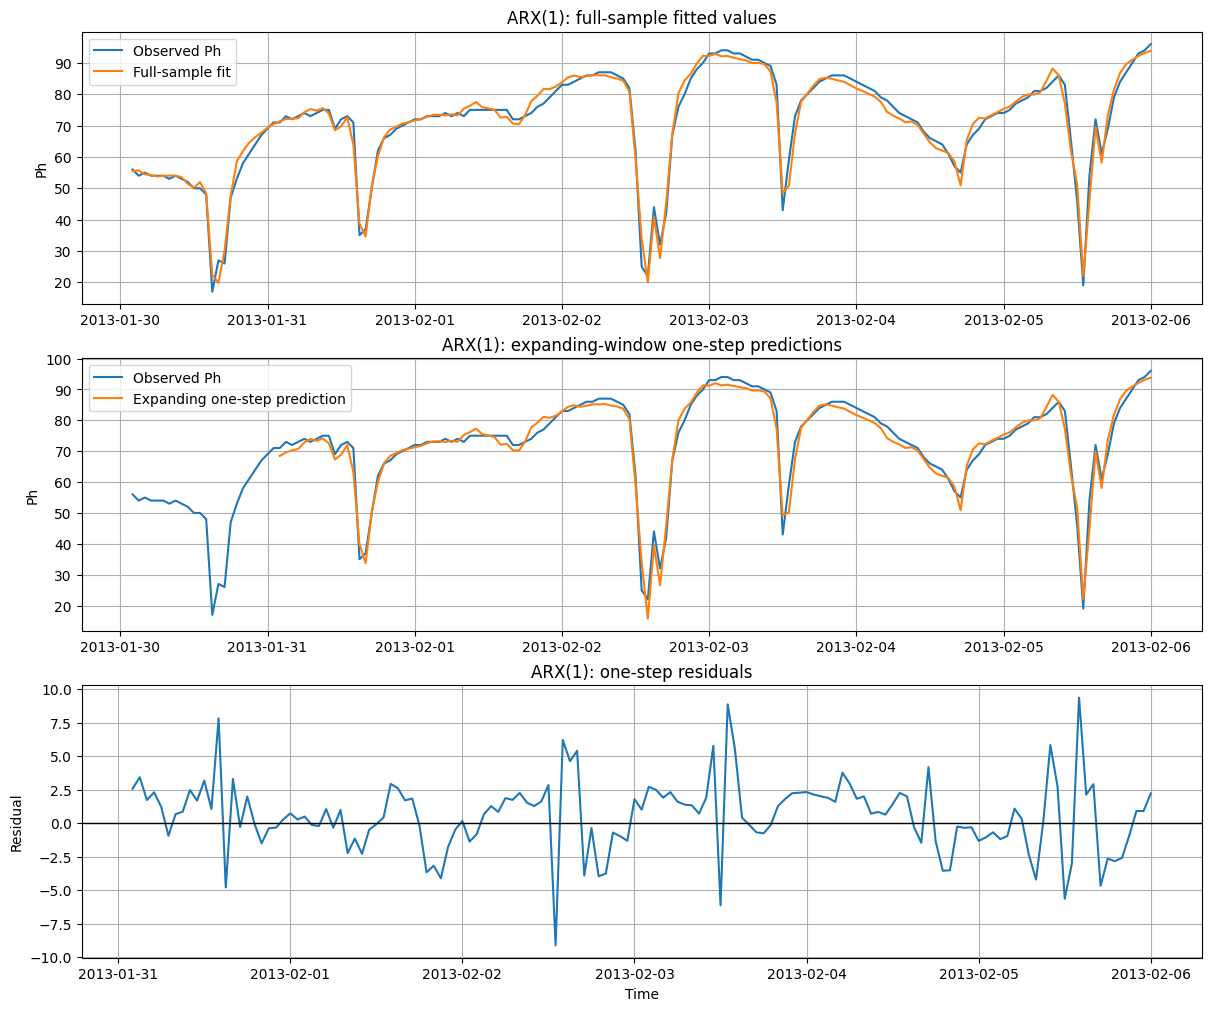

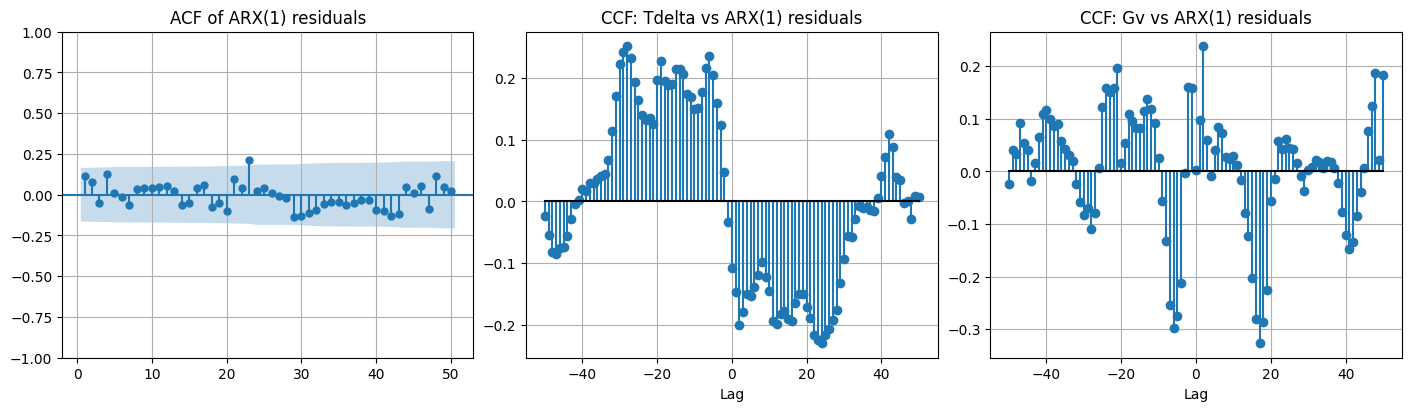

In [12]:
# Question 3.6: fit ARX(1) and compare the diagnostics with the static regression.
# Tiny check: the fit should improve and the residual dependence should become much smaller.
arx1_features = ["Ph.l1", "Tdelta", "Gv"]

arx1_model = sm.OLS(train["Ph"], sm.add_constant(train[arx1_features], has_constant="add")).fit()

train_arx1_fitted = arx1_model.predict(sm.add_constant(train[arx1_features], has_constant="add"))

train_arx1_pred, train_arx1_resid = expanding_one_step_predictions(
    df=train,
    feature_cols=arx1_features,
    target_col="Ph",
    min_train_size=24,
)

arx1_diag = train[["tdate", "Ph", "Tdelta", "Gv"]].copy()
arx1_diag["fitted_full_sample"] = train_arx1_fitted
arx1_diag["one_step_pred"] = train_arx1_pred
arx1_diag["one_step_resid"] = train_arx1_resid

display(pd.DataFrame({"coefficient": arx1_model.params.index, "estimate": arx1_model.params.values}))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

axes[0].plot(arx1_diag["tdate"], arx1_diag["Ph"], label="Observed Ph")
axes[0].plot(arx1_diag["tdate"], arx1_diag["fitted_full_sample"], label="Full-sample fit")
axes[0].set_title("ARX(1): full-sample fitted values")
axes[0].set_ylabel("Ph")
axes[0].legend()

axes[1].plot(arx1_diag["tdate"], arx1_diag["Ph"], label="Observed Ph")
axes[1].plot(arx1_diag["tdate"], arx1_diag["one_step_pred"], label="Expanding one-step prediction")
axes[1].set_title("ARX(1): expanding-window one-step predictions")
axes[1].set_ylabel("Ph")
axes[1].legend()

axes[2].plot(arx1_diag["tdate"], arx1_diag["one_step_resid"])
axes[2].axhline(0.0, color="black", linewidth=1.0)
axes[2].set_title("ARX(1): one-step residuals")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Residual")

plt.show()

resid_clean = arx1_diag["one_step_resid"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

plot_acf(resid_clean, lags=50, ax=axes[0], zero=False)
axes[0].set_title("ACF of ARX(1) residuals")

lags_td, ccf_td_res = sample_ccf(arx1_diag.loc[resid_clean.index, "Tdelta"], resid_clean, max_lag=50)
axes[1].stem(lags_td, ccf_td_res, linefmt="C0-", markerfmt="C0o", basefmt="k-")
axes[1].set_title("CCF: Tdelta vs ARX(1) residuals")
axes[1].set_xlabel("Lag")

lags_gv, ccf_gv_res = sample_ccf(arx1_diag.loc[resid_clean.index, "Gv"], resid_clean, max_lag=50)
axes[2].stem(lags_gv, ccf_gv_res, linefmt="C0-", markerfmt="C0o", basefmt="k-")
axes[2].set_title("CCF: Gv vs ARX(1) residuals")
axes[2].set_xlabel("Lag")

plt.show()

### What to notice
This is where the improvement should become visible. A lower RMSE, a flatter residual ACF, and weaker residual CCFs all point in the same direction: ARX(1) captures more of the system dynamics.

## Questions 3.7 and 3.8 — Increase the ARX order, compare AIC/BIC, and compare one-step test RMSE

For model order $p$, we use the structure

$$
Ph_t
=
-\phi_1 Ph_{t-1} - \cdots - \phi_p Ph_{t-p}
+ \sum_{j=0}^{p-1} \omega_{1,j} Tdelta_{t-j}
+ \sum_{j=0}^{p-1} \omega_{2,j} Gv_{t-j}
+ \varepsilon_t.
$$

So each increase in order adds:

- one extra lag of $Ph$
- one extra lag of $Tdelta$
- one extra lag of $Gv$

We now compare model orders 1 to 10 using:

- **AIC**
- **BIC**
- **test one-step RMSE**

,order,AIC,BIC,test_RMSE
0,1,794.627,807.099,3.663
1,2,748.671,770.497,3.195
2,3,732.749,763.929,2.830
3,4,707.944,748.478,2.958
4,5,700.407,750.295,3.046
5,6,686.727,745.969,3.314
6,7,688.250,756.846,3.283
7,8,693.090,771.040,3.274
8,9,697.449,784.753,3.282
9,10,696.865,793.523,3.301


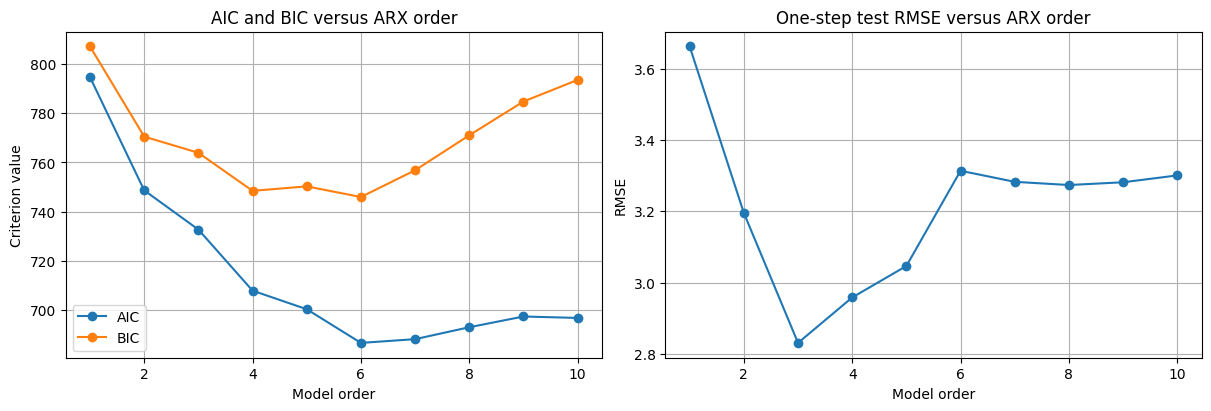

Best order by AIC : 6
Best order by BIC : 6
Best order by RMSE: 3


In [13]:
# Questions 3.7-3.8: compare ARX orders using AIC, BIC, and one-step test RMSE.
# Tiny check: the best in-sample order does not have to match the best test-set order.
def arx_feature_names(order):
    ph_lags = [f"Ph.l{k}" for k in range(1, order + 1)]
    tdelta_lags = [f"Tdelta.l{k}" for k in range(0, order)]
    gv_lags = [f"Gv.l{k}" for k in range(0, order)]
    return ph_lags + tdelta_lags + gv_lags

orders = np.arange(1, 11)
aic_values = []
bic_values = []
rmse_values = []

for order in orders:
    features = arx_feature_names(order)

    X_train = sm.add_constant(train[features], has_constant="add")
    y_train = train["Ph"]
    fit = sm.OLS(y_train, X_train).fit()

    aic_values.append(fit.aic)
    bic_values.append(fit.bic)

    X_test = sm.add_constant(test[features], has_constant="add")
    y_test = test["Ph"]
    y_pred_test = fit.predict(X_test)

    rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
    rmse_values.append(rmse)

order_table = pd.DataFrame(
    {
        "order": orders,
        "AIC": np.round(aic_values, 3),
        "BIC": np.round(bic_values, 3),
        "test_RMSE": np.round(rmse_values, 3),
    }
)
display(order_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(orders, aic_values, marker="o", label="AIC")
axes[0].plot(orders, bic_values, marker="o", label="BIC")
axes[0].set_title("AIC and BIC versus ARX order")
axes[0].set_xlabel("Model order")
axes[0].set_ylabel("Criterion value")
axes[0].legend()

axes[1].plot(orders, rmse_values, marker="o")
axes[1].set_title("One-step test RMSE versus ARX order")
axes[1].set_xlabel("Model order")
axes[1].set_ylabel("RMSE")

plt.show()

best_aic_order = int(orders[np.argmin(aic_values)])
best_bic_order = int(orders[np.argmin(bic_values)])
best_rmse_order = int(orders[np.argmin(rmse_values)])

print("Best order by AIC :", best_aic_order)
print("Best order by BIC :", best_bic_order)
print("Best order by RMSE:", best_rmse_order)

### What to notice
It is common that AIC/BIC and test RMSE do not agree perfectly. In practice, this cell helps you balance in-sample fit against out-of-sample prediction performance.

### Choosing the working ARX order for the final multi-step simulation

AIC and BIC are **in-sample** criteria and often favor slightly larger models.  
The one-step test RMSE is an **out-of-sample** forecasting criterion and is often more relevant for prediction quality.

For that reason, the notebook uses the **best test-RMSE order** as the working choice for the multi-step simulation.

## Question 3.9 — Multi-step prediction (simulation) through the full period

In this setting, the output lags are no longer taken from the true future $Ph$ values.  
Instead, they are generated recursively from the model’s own past predictions.

This is the key difference between:

- **one-step prediction**: uses the observed lagged output
- **multi-step simulation**: uses the model’s own predicted lagged output

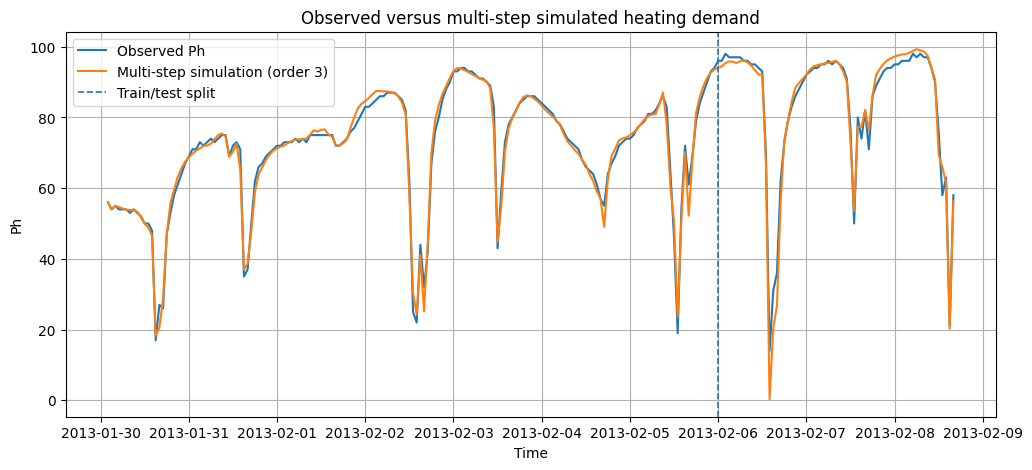

Full-path simulation RMSE (excluding the first 3 warm-up points): 2.499


In [14]:
# Question 3.9: run the recursive multi-step simulation with the chosen ARX order.
# Tiny check: broad patterns should be captured, but sharp peaks are usually harder in recursive simulation.
selected_order = best_rmse_order

selected_features = arx_feature_names(selected_order)
selected_model = sm.OLS(
    train["Ph"],
    sm.add_constant(train[selected_features], has_constant="add")
).fit()

params = selected_model.params

ph_sim = np.full(len(box), np.nan)

ph_sim[:selected_order] = box["Ph"].iloc[:selected_order].to_numpy()

for t in range(selected_order, len(box)):
    pred = params["const"]

    for lag in range(1, selected_order + 1):
        pred += params[f"Ph.l{lag}"] * ph_sim[t - lag]

    for lag in range(0, selected_order):
        pred += params[f"Tdelta.l{lag}"] * box.iloc[t][f"Tdelta.l{lag}"]
        pred += params[f"Gv.l{lag}"] * box.iloc[t][f"Gv.l{lag}"]

    ph_sim[t] = pred

simulation_df = box[["tdate", "Ph"]].copy()
simulation_df["Ph_simulated"] = ph_sim

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(simulation_df["tdate"], simulation_df["Ph"], label="Observed Ph")
ax.plot(simulation_df["tdate"], simulation_df["Ph_simulated"], label=f"Multi-step simulation (order {selected_order})")

ax.axvline(train_end, linestyle="--", linewidth=1.2, label="Train/test split")

ax.set_title("Observed versus multi-step simulated heating demand")
ax.set_xlabel("Time")
ax.set_ylabel("Ph")
ax.legend()

plt.show()

full_sim_rmse = np.sqrt(np.mean((simulation_df["Ph"].iloc[selected_order:] - simulation_df["Ph_simulated"].iloc[selected_order:]) ** 2))
print(f"Full-path simulation RMSE (excluding the first {selected_order} warm-up points): {full_sim_rmse:.3f}")

### What to notice
Recursive simulation is harder than one-step prediction because past simulation errors can carry forward. A useful model should still follow the broad pattern, even if some sharp turns get smoothed out.

## Question 3.10 — Short concluding remarks

A concise course-based conclusion is:

- The exploratory plots show that $Ph$ has clear serial dependence and a meaningful relation to both $Tdelta$ and $Gv$.
- The simple static regression captures part of the signal, but the residual ACF and CCF still reveal remaining dynamic structure.
- ARX(1) improves the one-step fit and typically reduces residual autocorrelation.
- Higher-order ARX models improve in-sample fit further, but the best **out-of-sample** order may be smaller than the AIC/BIC optimum.
- Multi-step simulation is harder than one-step prediction because recursive output lags accumulate error over time.

This is exactly why the assignment asks for both:
- **in-sample criteria** such as AIC/BIC
- **out-of-sample criteria** such as test RMSE